## 模型訓練與評估 (Model Training & Evaluation) 

### 1. 載入已清洗的資料

In [35]:
import joblib
import pandas as pd

# 1. 從指定路徑載入 01 號檔案的存檔
# 請確認您的相對路徑正確 (../ 代表回上一層，再進入 01_data)
data_path = '../01_data/cleaned_job_data.joblib'
df = joblib.load(data_path)

print(f"✅ 資料載入成功！目前的數據維度：{df.shape}")

# 預覽資料，確認 text 欄位與標籤都在
df.head()

✅ 資料載入成功！目前的數據維度：(17880, 19)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text
0,1,Marketing Intern,"US, NY, New York",Marketing,,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,,,Marketing,0,marketing intern food a fast growing james bea...
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,,Marketing and Advertising,Customer Service,0,customer service cloud video production organi...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",,,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,,,,,,0,commissioning machinery assistant cma our clie...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,account executive washington dc the company es...
4,5,Bill Review Manager,"US, FL, Fort Worth",,,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,bill review manager job title itemization revi...


### 2. 資料集切分 (Train-Test Split)

In [36]:
from sklearn.model_selection import train_test_split

# 1. 定義 X (特徵) 與 y (標籤)
# 我們選取合併後的 text 以及兩項關鍵行為指標
X = df[['text', 'has_company_logo', 'has_questions']]
y = df['fraudulent']

# 2. 執行資料集切分
# test_size=0.2: 撥出 20% 作為最終考試題
# random_state=42: 確保每次執行的切分結果一致
# stratify=y: 極重要！確保訓練/測試集的詐騙比例與原始資料相同
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ 資料集切分完成！")
print(f"---------------------------------")
print(f"訓練集 (X_train): {X_train.shape[0]} 筆")
print(f"測試集 (X_test):  {X_test.shape[0]} 筆")
print(f"訓練集詐騙比例:   {y_train.mean():.2%}")
print(f"測試集詐騙比例:   {y_test.mean():.2%}")

✅ 資料集切分完成！
---------------------------------
訓練集 (X_train): 14304 筆
測試集 (X_test):  3576 筆
訓練集詐騙比例:   4.84%
測試集詐騙比例:   4.84%


### 3. 自動化管線 (Scikit-Learn Pipeline) 

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# 1. 定義文字轉換器：將清洗後的 text 轉為 TF-IDF 向量
# max_features=500: 只保留最重要的 500 個關鍵字，避免特徵過多導致運算太慢
tfidf = TfidfVectorizer(max_features=500)

# 2. 建立「欄位轉換器」 (ColumnTransformer)：
# 針對 'text' 欄位套用 tfidf
# 其餘欄位 (has_company_logo, has_questions) 則保持原樣 (passthrough)
preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', tfidf, 'text')
    ],
    remainder='passthrough'
)

# 3. 建立「最終管線」 (Pipeline)：
# 第一步：preprocessor (負責把文字變數字、整合所有特徵)
# 第二步：classifier (負責學習與分類，這裡使用隨機森林)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("=== Step 7-2 自動化管線定義完成 ===")
print(model_pipeline)

=== Step 7-2 自動化管線定義完成 ===
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('text_vec',
                                                  TfidfVectorizer(max_features=500),
                                                  'text')])),
                ('classifier', RandomForestClassifier(random_state=42))])


### 4. 演算法選擇：隨機森林 (Random Forest) 

In [38]:
# 1. 正式開始訓練模型
# 餵入訓練集 (X_train, y_train)
# 注意：這一步可能需要 5-15 秒，具體視電腦效能而定
print("--- 正在訓練隨機森林模型與 TF-IDF 向量化中... ---")
model_pipeline.fit(X_train, y_train)

print("=== Step 7-3 模型訓練完成 ===")

--- 正在訓練隨機森林模型與 TF-IDF 向量化中... ---
=== Step 7-3 模型訓練完成 ===


### 5. 模型評估 (Model Evaluation)

=== Step 7-5 模型評估報告 ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.49      0.66       173

    accuracy                           0.98      3576
   macro avg       0.99      0.75      0.82      3576
weighted avg       0.98      0.98      0.97      3576



<Figure size 600x400 with 0 Axes>

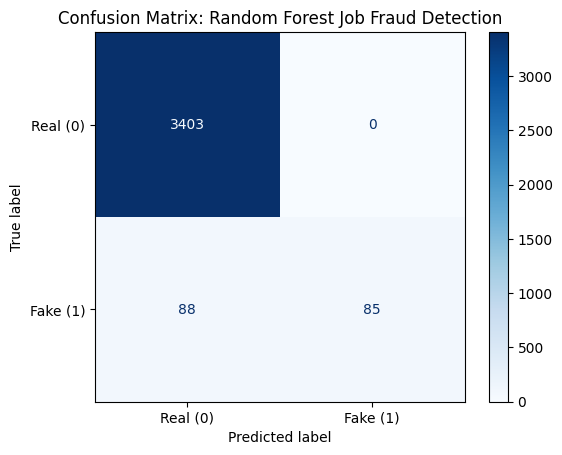

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. 使用測試集進行預測
y_pred = model_pipeline.predict(X_test)

# 2. 顯示分類報告
print("=== Step 7-5 模型評估報告 ===")
print(classification_report(y_test, y_pred))

# 3. 繪製混淆矩陣 (Confusion Matrix)
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (0)', 'Fake (1)'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Random Forest Job Fraud Detection')
plt.show()

### 6. 模型優化：處理不平衡與增強特徵

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# 1. 強化文字特徵：增加詞彙量並加入雙字詞 (N-grams)
# max_features=2000: 擴大字典容量
# ngram_range=(1, 2): 讓模型學會 'work from home', 'money back' 這種詞組
tfidf_v2 = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))

# 2. 欄位轉換器保持一致
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('text_vec', tfidf_v2, 'text')
    ],
    remainder='passthrough'
)

# 3. 隨機森林核心優化：
# class_weight='balanced': 這是提升 Recall 的原子彈，讓模型對詐騙樣本更敏感
model_pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('classifier', RandomForestClassifier(
        n_estimators=150, 
        class_weight='balanced', 
        random_state=42,
        n_jobs=-1
    ))
])

print("=== Step 7-5 [優化版] 管線定義完成 ===")

=== Step 7-5 [優化版] 管線定義完成 ===


### 7. 模型訓練 (強化版 - Optimized Training)

In [41]:
# 使用優化後的管線進行訓練
# 這次模型會特別關注那些被標記為「詐騙 (1)」的少數樣本
print("--- 正在訓練優化版模型 (導入 N-grams 與 Class Balance)... ---")
model_pipeline_v2.fit(X_train, y_train)

print("=== Step 7-6 [優化版] 模型訓練完成 ===")

--- 正在訓練優化版模型 (導入 N-grams 與 Class Balance)... ---
=== Step 7-6 [優化版] 模型訓練完成 ===


### 8. 評估優化版模型 (Optimized Model Evaluation)

=== Step 7-8 [優化版] 模型評估報告 ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.50      0.67       173

    accuracy                           0.98      3576
   macro avg       0.99      0.75      0.83      3576
weighted avg       0.98      0.98      0.97      3576



<Figure size 600x400 with 0 Axes>

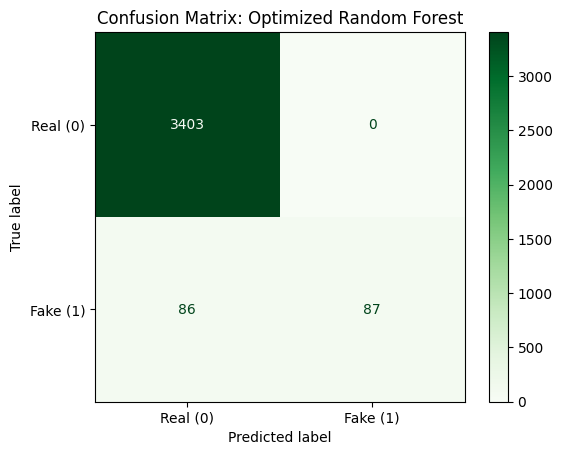

In [51]:
# 1. 使用優化後的模型進行預測
y_pred_v2 = model_pipeline_v2.predict(X_test)

# 2. 顯示優化後的分類報告
print("=== Step 7-8 [優化版] 模型評估報告 ===")
print(classification_report(y_test, y_pred_v2))

# 3. 繪製優化後的混淆矩陣
plt.figure(figsize=(6, 4))
cm_v2 = confusion_matrix(y_test, y_pred_v2)
disp_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=['Real (0)', 'Fake (1)'])
disp_v2.plot(cmap='Greens', values_format='d') # 改用綠色色調區分版本

plt.title('Confusion Matrix: Optimized Random Forest')
# 建議手動存檔為 'Evaluation_Confusion_Matrix_Optimized.png'
plt.show()

---

### 9. 定義 XGBoost 強化版管線

In [43]:
from xgboost import XGBClassifier

# 1. 計算類別權重比例 (解決不平衡的核心)
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# 2. 定義 XGBoost 管線
# 我們沿用之前的 preprocessor_v2 (包含 TF-IDF 2000 個特徵與 N-grams)
model_pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=ratio, # 自動套用 19.6 倍的懲罰權重
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

print(f"=== Step 7-8 XGBoost 管線定義完成 ===")
print(f"目前的類別權重比例 (scale_pos_weight) 設定為: {ratio:.2f}")

=== Step 7-8 XGBoost 管線定義完成 ===
目前的類別權重比例 (scale_pos_weight) 設定為: 19.64


### 10. 訓練 XGBoost 模型 (XGBoost Training)

In [44]:
# 開始訓練 XGBoost 模型
# 由於 XGBoost 具有 scale_pos_weight，訓練過程中會對標籤 1 給予極高關注
print("--- 正在訓練 XGBoost 強化版模型 (引擎換裝中)... ---")
model_pipeline_xgb.fit(X_train, y_train)

print("=== Step 7-10 XGBoost 訓練完成 ===")

--- 正在訓練 XGBoost 強化版模型 (引擎換裝中)... ---


d:\00_學習\06_TibaMe 數據分析人才養成班\08_個人專題\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:49:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Step 7-10 XGBoost 訓練完成 ===


### 11. 評估 XGBoost 模型 (XGBoost Evaluation)

=== Step 7-11 XGBoost 模型評估報告 ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.59      0.79      0.67       173

    accuracy                           0.96      3576
   macro avg       0.79      0.88      0.83      3576
weighted avg       0.97      0.96      0.97      3576



<Figure size 600x400 with 0 Axes>

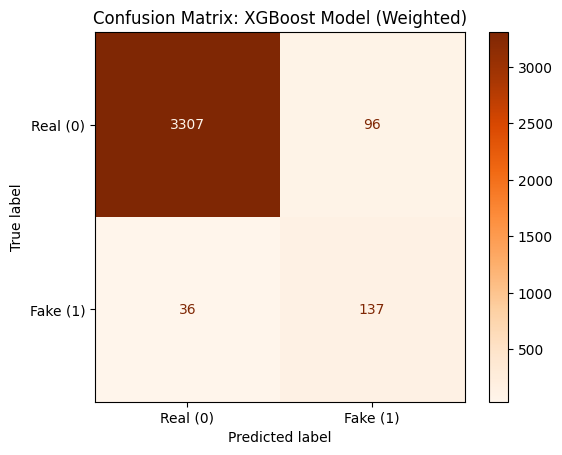

In [45]:
# 1. 使用測試集進行預測
y_pred_xgb = model_pipeline_xgb.predict(X_test)

# 2. 顯示 XGBoost 的分類報告
print("=== Step 7-11 XGBoost 模型評估報告 ===")
print(classification_report(y_test, y_pred_xgb))

# 3. 繪製 XGBoost 的混淆矩陣
plt.figure(figsize=(6, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Real (0)', 'Fake (1)'])
disp_xgb.plot(cmap='Oranges', values_format='d') # 改用橘色調區分 XGBoost 版本

plt.title('Confusion Matrix: XGBoost Model (Weighted)')
# 建議手動存檔為 'Evaluation_Confusion_Matrix_XGBoost.png'
plt.show()

### 12. 精準版 - XGBoost 管線調整

In [46]:
# 將比例從 19.64 降為 10，讓模型不要那麼「敏感」
conservative_ratio = 10 

model_pipeline_xgb_precision = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=conservative_ratio, # 降低權重
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

print(f"=== Step 7-12 [精準版] XGBoost 定義完成 ===")
print(f"權重已從 19.64 調降為: {conservative_ratio}")

=== Step 7-12 [精準版] XGBoost 定義完成 ===
權重已從 19.64 調降為: 10


### 13. 訓練與評估：精準版 - XGBoost

--- 正在訓練精準版 XGBoost 模型 (權重=10)... ---


d:\00_學習\06_TibaMe 數據分析人才養成班\08_個人專題\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:50:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Step 7-13 [精準版] 模型評估報告 ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.75      0.73      0.74       173

    accuracy                           0.98      3576
   macro avg       0.87      0.86      0.86      3576
weighted avg       0.98      0.98      0.98      3576



<Figure size 600x400 with 0 Axes>

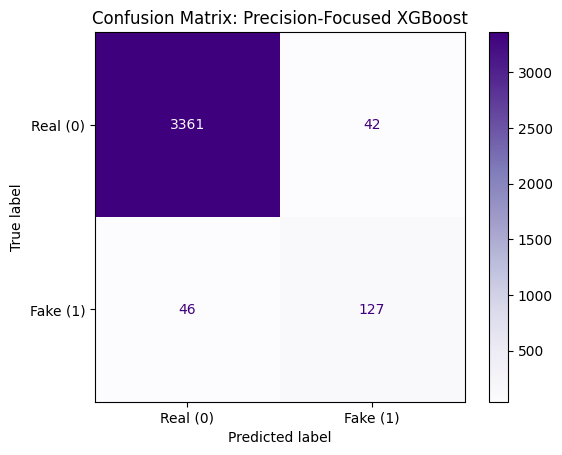

In [47]:
# 1. 訓練精準版模型
print("--- 正在訓練精準版 XGBoost 模型 (權重=10)... ---")
model_pipeline_xgb_precision.fit(X_train, y_train)

# 2. 進行預測
y_pred_prec = model_pipeline_xgb_precision.predict(X_test)

# 3. 顯示評估報告
print("\n=== Step 7-13 [精準版] 模型評估報告 ===")
print(classification_report(y_test, y_pred_prec))

# 4. 繪製混淆矩陣
plt.figure(figsize=(6, 4))
cm_prec = confusion_matrix(y_test, y_pred_prec)
disp_prec = ConfusionMatrixDisplay(confusion_matrix=cm_prec, display_labels=['Real (0)', 'Fake (1)'])
disp_prec.plot(cmap='Purples', values_format='d') # 改用紫色調區分

plt.title('Confusion Matrix: Precision-Focused XGBoost')
plt.show()

### 14. 定義 SVM 管線

In [48]:
from sklearn.svm import SVC

# 定義 SVM 管線
# kernel='linear': 對於文字 TF-IDF 特徵，線性核通常效果最好且速度快
# class_weight='balanced': 自動根據樣本比例調整懲罰權重
# probability=True: 之後若想調整閾值（Threshold），需要開啟此功能
model_pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('classifier', SVC(
        kernel='linear', 
        class_weight='balanced', 
        probability=True, 
        random_state=42
    ))
])

print("=== Step 7-14 SVM 管線定義完成 ===")

=== Step 7-14 SVM 管線定義完成 ===


### 15. 訓練與評估 SVM

--- 正在訓練 SVM 模型 (尋找最佳超平面中)... ---

=== Step 7-15 SVM 模型評估報告 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3403
           1       0.50      0.86      0.63       173

    accuracy                           0.95      3576
   macro avg       0.75      0.91      0.80      3576
weighted avg       0.97      0.95      0.96      3576



<Figure size 600x400 with 0 Axes>

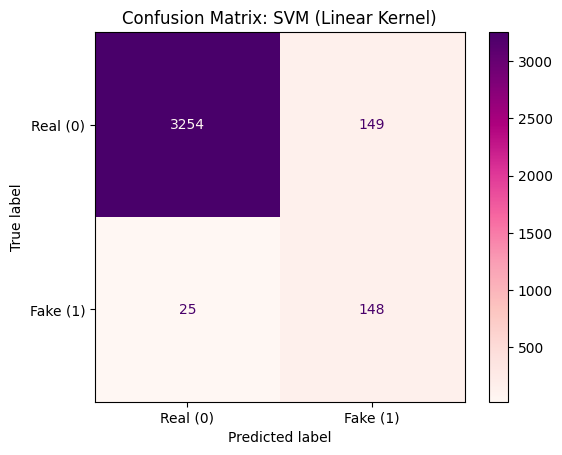

In [49]:
# 1. 訓練 SVM 模型
print("--- 正在訓練 SVM 模型 (尋找最佳超平面中)... ---")
model_pipeline_svm.fit(X_train, y_train)

# 2. 進行預測
y_pred_svm = model_pipeline_svm.predict(X_test)

# 3. 顯示評估報告
print("\n=== Step 7-15 SVM 模型評估報告 ===")
print(classification_report(y_test, y_pred_svm))

# 4. 繪製混淆矩陣
plt.figure(figsize=(6, 4))
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Real (0)', 'Fake (1)'])
disp_svm.plot(cmap='RdPu', values_format='d') # 使用紅紫色調區分

plt.title('Confusion Matrix: SVM (Linear Kernel)')
plt.show()

### 16. 封裝 SVM 模型

In [55]:
import joblib
import os

# 1. 確保 models 目錄存在 (根據您的目錄結構，從 notebooks 往上一層找 models)
os.makedirs('../02_models', exist_ok=True)

# 2. 將 SVM 冠軍模型管線存檔
# 這裡我們使用您規劃的檔名，並存入根目錄下的 models 資料夾
model_path = '../02_models/fraud_detection_pipeline.pkl'
joblib.dump(model_pipeline_svm, model_path)

print(f"✅ SVM 冠軍模型已成功存檔至: {model_path}")

✅ SVM 冠軍模型已成功存檔至: ../02_models/fraud_detection_pipeline.pkl


### 17. 封裝 XGBoost 模型

In [56]:
# 將之前的 XGBoost 精準版模型存檔
xgb_model_path = '../02_models/xgb_model_precision.pkl'
joblib.dump(model_pipeline_xgb_precision, xgb_model_path)

print(f"✅ XGBoost 模型已成功存檔至: {xgb_model_path}")

✅ XGBoost 模型已成功存檔至: ../02_models/xgb_model_precision.pkl


---
---
